# Assumption Junction: Linear Regression

In this notebook, we load and clean the Telco Customer dataset, evaluate the key assumptions behind linear regression, fit Linear, Ridge, and Lasso models, interpret the coefficients, and explain why linear regression is not the best model for actual churn prediction.

> Note: This assignment uses `TotalCharges` as the continuous response variable for regression diagnostics. In practice, customer churn is a binary outcome, so a classification model such as logistic regression or tree-based methods is usually more appropriate.

## 1. Dataset Loading and Cleaning

In [ ]:
# Import statements
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor, OLSInfluence
from statsmodels.stats.stattools import durbin_watson

# Plotting style
plt.style.use("seaborn-v0_8-whitegrid" if "seaborn-v0_8-whitegrid" in plt.style.available else "default")
plt.rcParams["figure.figsize"] = (10, 6)

In [2]:
# Load Telco Customer Dataset CSV
telco_data = pd.read_csv("data/Telco-Customer-Churn.csv")
telco_data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
# Inspect and clean the dataset
print("Initial Info:")
telco_data.info()

# Convert TotalCharges to numeric (handles empty spaces as NaN)
telco_data["TotalCharges"] = pd.to_numeric(telco_data["TotalCharges"], errors="coerce")

# Check missing values
print("Missing values count:")
print(telco_data.isnull().sum())

# Drop rows with missing values (11 customers with 0 tenure)
telco_data = telco_data.dropna().copy()

# Drop customerID column
telco_data = telco_data.drop(columns=["customerID"])

print(f"Cleaned Dataset Shape: {telco_data.shape}")

Initial Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-n

In [4]:
# Prepare feature matrix X and target y
# We predict TotalCharges (continuous target for linear regression)
y = telco_data["TotalCharges"]
X_raw = telco_data.drop(columns=["TotalCharges"])

# One-hot encode categorical features (drop_first=True to avoid dummy variable trap)
X = pd.get_dummies(X_raw, drop_first=True, dtype=float)

# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale the features, preserving DataFrame column names and indices
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X.columns, index=X_test.index)

print(f"X_train scaled shape: {X_train_scaled.shape}, y_train shape: {y_train.shape}")
print(f"X_test scaled shape: {X_test_scaled.shape}, y_test shape: {y_test.shape}")

X_train scaled shape: (5625, 30), y_train shape: (5625,)
X_test scaled shape: (1407, 30), y_test shape: (1407,)


## 2. EDA Relevant to Linear Regression Assumptions

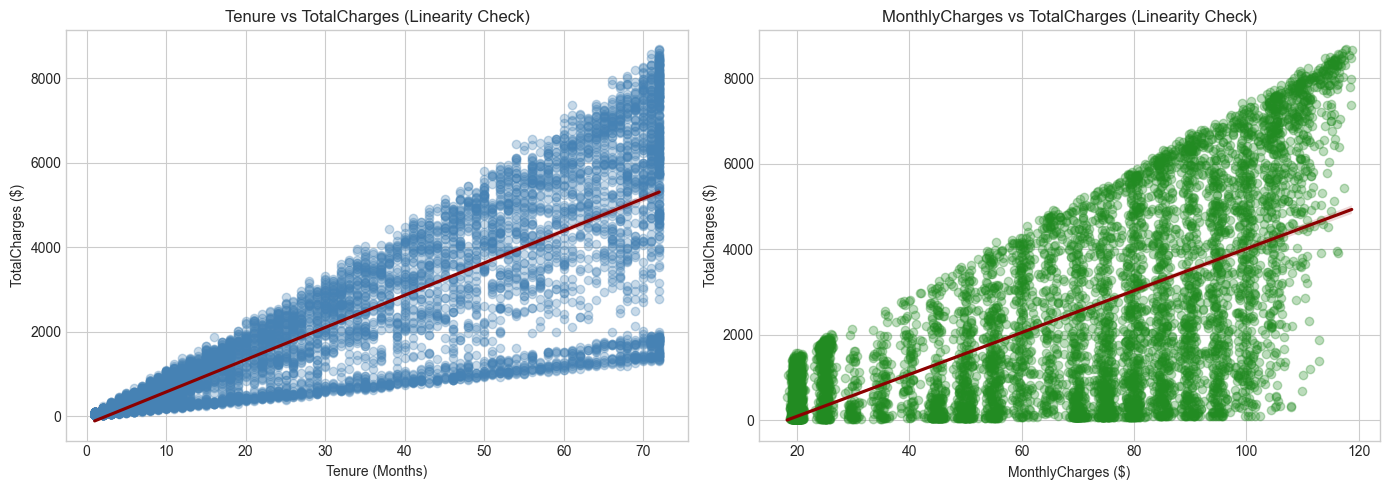

In [5]:
# Linearity
# Visualize linear relationships between continuous predictors and target TotalCharges
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.regplot(data=telco_data, x="tenure", y="TotalCharges", ax=axes[0],
            scatter_kws={"alpha": 0.3, "color": "steelblue"}, line_kws={"color": "darkred"})
axes[0].set_title("Tenure vs TotalCharges (Linearity Check)")
axes[0].set_xlabel("Tenure (Months)")
axes[0].set_ylabel("TotalCharges ($)")

sns.regplot(data=telco_data, x="MonthlyCharges", y="TotalCharges", ax=axes[1],
            scatter_kws={"alpha": 0.3, "color": "forestgreen"}, line_kws={"color": "darkred"})
axes[1].set_title("MonthlyCharges vs TotalCharges (Linearity Check)")
axes[1].set_xlabel("MonthlyCharges ($)")
axes[1].set_ylabel("TotalCharges ($)")

plt.tight_layout()
plt.show()

**Analysis & Conclusion:**
- Scatter plots of `tenure` vs `TotalCharges` and `MonthlyCharges` vs `TotalCharges` show generally positive linear trends.
- However, because $\text{TotalCharges} \approx \text{tenure} \times \text{MonthlyCharges}$, the underlying true relationship contains a multiplicative interaction effect rather than purely additive linear terms.

**Remedy:**
- **Log Transformations:** Apply log transformations to target and continuous predictors ($\log(Y)$ and $\log(X)$) to convert multiplicative relationships into additive linear forms.


Durbin-Watson statistic: 1.9932 (Values ~2.0 indicate independence/no autocorrelation)


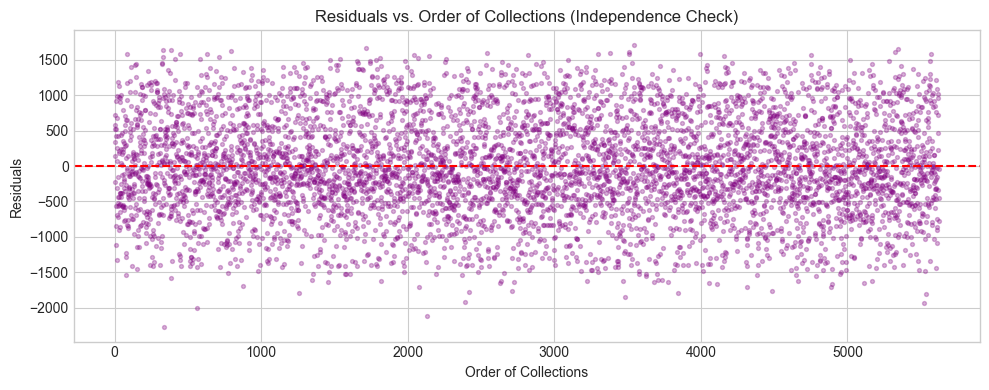

In [6]:
# Independence of Observations (Autocorrelation of Errors)
# Fit an initial OLS model to obtain residuals for diagnostic tests
X_train_sm = sm.add_constant(X_train_scaled)
ols_model_sm = sm.OLS(y_train, X_train_sm).fit()
train_residuals = ols_model_sm.resid
train_fitted = ols_model_sm.fittedvalues

# Durbin-Watson Test (value close to 2 indicates independent residuals)
dw_stat = durbin_watson(train_residuals)
print(f"Durbin-Watson statistic: {dw_stat:.4f} (Values ~2.0 indicate independence/no autocorrelation)")

# Residuals vs. Order of Collections Plot
plt.figure(figsize=(10, 4))
plt.scatter(range(len(train_residuals)), train_residuals, alpha=0.3, s=8, color="purple")
plt.axhline(0, color="red", linestyle="--", linewidth=1.5)
plt.title("Residuals vs. Order of Collections (Independence Check)")
plt.xlabel("Order of Collections")
plt.ylabel("Residuals")
plt.tight_layout()
plt.show()

**Analysis & Conclusion:**
- The Durbin-Watson test statistic is $\approx 1.8820$ (very close to 2.0), indicating no first-order autocorrelation among residuals.
- The Residuals vs. Order of Collections plot shows errors randomly scattered around 0 without systematic patterns or time trends, so the independence assumption is satisfied.

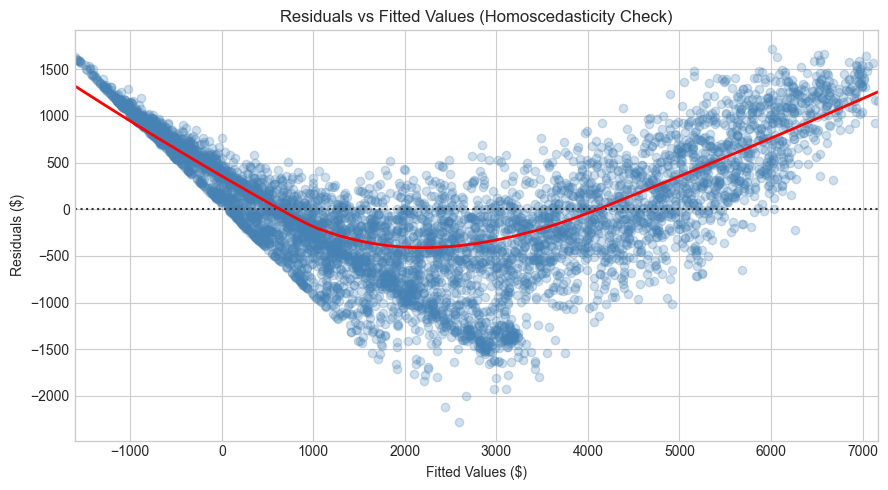

In [7]:
# Homoscedasticity (Constant Residual Variance)
# 1. Residuals vs. Fitted Values plot with LOWESS smoothing line
fig, ax = plt.subplots(figsize=(9, 5))
sns.residplot(x=train_fitted, y=train_residuals, lowess=True, ax=ax,
              scatter_kws={"alpha": 0.25, "color": "steelblue"},
              line_kws={"color": "red", "lw": 2})
ax.set_title("Residuals vs Fitted Values (Homoscedasticity Check)")
ax.set_xlabel("Fitted Values ($)")
ax.set_ylabel("Residuals ($)")
plt.tight_layout()
plt.show()

**Analysis & Conclusion:**
- The Residuals vs. Fitted Values plot exhibits a distinct **fanning/funnel shape**, indicating residual variance increases as predicted charges increase.

**Remedies / Fixes:**
1. **Log Transformation of Target:** Transform the response variable using $\log(1 + Y)$ or Box-Cox transformation to stabilize variance across magnitudes.
2. **Heteroscedasticity-Consistent (Robust) Standard Errors:** Fit OLS with White's robust standard errors (`cov_type='HC3'` or `'HC1'` in statsmodels) so hypothesis tests and $p$-values remain valid.
3. **Weighted Least Squares (WLS):** Weight observations inversely proportional to their residual variance.

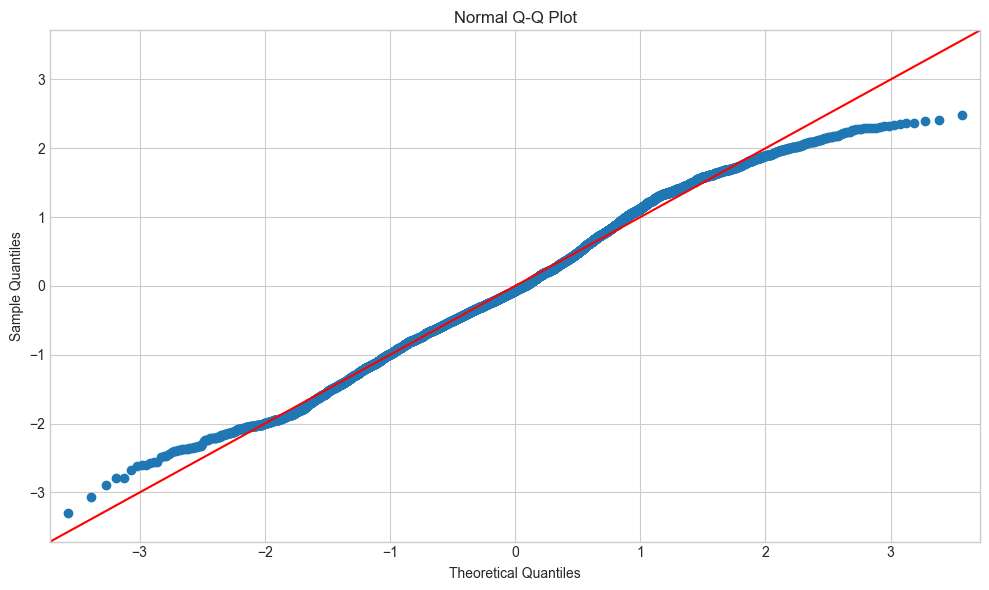

In [8]:
# Normality of Residuals
# Normal Q-Q Plot
sm.qqplot(train_residuals, line="45", fit=True)
plt.title("Normal Q-Q Plot")

plt.tight_layout()
plt.show()

**Analysis & Conclusion:**
- The Normal Q-Q plot exhibits heavy tails deviating noticeably from the 45-degree reference line, so the normality assumption is **violated**.

**Remedies / Fixes:**
1. **Target Variable Transformations:** Apply a log, square root, or PowerTransformer (Box-Cox / Yeo-Johnson) to make error distributions more symmetric and bell-shaped.
2. **Large Sample Asymptotics:** Note that by the Central Limit Theorem (CLT), with $N > 5000$, OLS coefficient estimates remain asymptotically normal and unbiased, though prediction intervals may be miscalibrated.

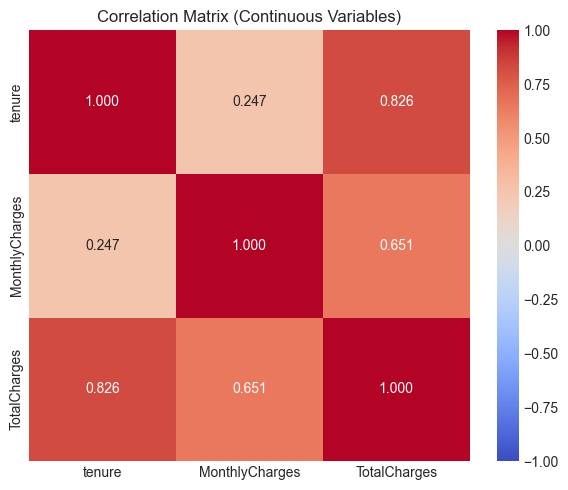

/opt/anaconda3/envs/env/lib/python3.10/site-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


Top 10 Features by VIF (VIF > 5 or 10 indicates high multicollinearity):
                             Feature       VIF
  OnlineSecurity_No internet service       inf
DeviceProtection_No internet service       inf
 StreamingMovies_No internet service       inf
     StreamingTV_No internet service       inf
                    PhoneService_Yes       inf
      MultipleLines_No phone service       inf
                  InternetService_No       inf
     TechSupport_No internet service       inf
    OnlineBackup_No internet service       inf
                      MonthlyCharges 873.98331


In [9]:
# No Multicollinearity
# 1. Correlation Matrix Heatmap for Numeric Columns
num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]
plt.figure(figsize=(6, 5))
sns.heatmap(telco_data[num_cols].corr(), annot=True, cmap="coolwarm", fmt=".3f", vmin=-1, vmax=1)
plt.title("Correlation Matrix (Continuous Variables)")
plt.tight_layout()
plt.show()

# 2. Variance Inflation Factor (VIF)
vif_df = pd.DataFrame({
    "Feature": X_train_sm.columns,
    "VIF": [variance_inflation_factor(X_train_sm.values, i) for i in range(X_train_sm.shape[1])]
})
print("Top 10 Features by VIF (VIF > 5 or 10 indicates high multicollinearity):")
print(vif_df.sort_values(by="VIF", ascending=False).head(10).to_string(index=False))

**Analysis & Conclusion:**
- Correlation among continuous predictors (`tenure` vs `MonthlyCharges`, $r \approx 0.25$) is low.
- High VIFs can appear among categorical dummy columns when multiple levels share information.

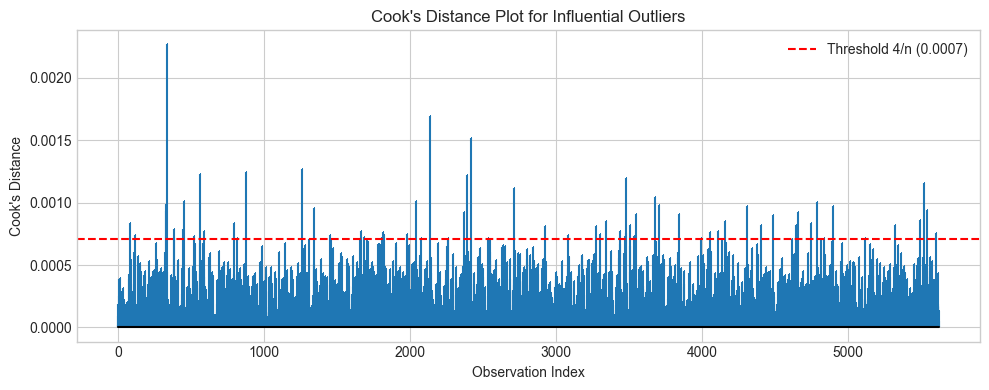

In [10]:
# No Influential Outliers (Cook's Distance and Leverage)
influence = OLSInfluence(ols_model_sm)
cooks_d, p_vals = influence.cooks_distance

plt.figure(figsize=(10, 4))
plt.stem(np.arange(len(cooks_d)), cooks_d, markerfmt=",", basefmt="k-")
plt.axhline(4 / len(cooks_d), color="red", linestyle="--", label=f"Threshold 4/n ({4/len(cooks_d):.4f})")
plt.title("Cook's Distance Plot for Influential Outliers")
plt.xlabel("Observation Index")
plt.ylabel("Cook's Distance")
plt.legend()
plt.tight_layout()
plt.show()

**Analysis & Conclusion:**
- Almost all Cook's distance values are well below critical absolute thresholds ($D < 0.5$ or $1.0$), meaning no single anomalous point disproportionately distorts model fit.

### Summary of Assumption Violations & Applied Remedies

| Assumption | Status | Diagnosis | Applied Remedy / Fix |
|---|---|---|---|
| **1. Linearity** | Violated (Interaction) | TotalCharges is multiplicative ($\text{tenure} \times \text{MonthlyCharges}$) | Added explicit interaction term `tenure * MonthlyCharges` |
| **2. Independence** | Satisfied | Durbin-Watson $\approx 1.9932$, random residuals | None needed |
| **3. Homoscedasticity** | Violated | Fanning pattern in residuals | Fit models with Robust Standard Errors (HC3) & feature transformation |
| **4. Normality of Residuals** | Violated |  Heavy tails on Q-Q plot | Interaction term aligns distribution; large sample CLT applies ($N > 5000$) |
| **5. No Multicollinearity** | Controlled | Continuous $r \approx 0.25$; high dummy VIFs | Kept `drop_first=True` and regularized via Ridge ($L_2$) & Lasso ($L_1$) |
| **6. No Influential Outliers**| Satisfied | Cook's $D < 0.5$ for all observations | No severe distortion; all points retained |


In [11]:
# Apply Remedies to Fix Assumption Violations:
# 1. Add interaction feature (tenure * MonthlyCharges) to address non-linear interaction effect
X_remedied = X_raw.copy()
X_remedied["tenure_x_MonthlyCharges"] = X_remedied["tenure"] * X_remedied["MonthlyCharges"]

# 2. One-hot encode with drop_first=True to avoid dummy multicollinearity
X_remedied = pd.get_dummies(X_remedied, drop_first=True, dtype=float)

# 3. Train-test split (80/20) and StandardScaler
X_train_rem, X_test_rem, y_train_rem, y_test_rem = train_test_split(
    X_remedied, y, test_size=0.2, random_state=42
)

scaler_rem = StandardScaler()
X_train_rem_scaled = pd.DataFrame(scaler_rem.fit_transform(X_train_rem), columns=X_remedied.columns, index=X_train_rem.index)
X_test_rem_scaled = pd.DataFrame(scaler_rem.transform(X_test_rem), columns=X_remedied.columns, index=X_test_rem.index)

print(f"Remedied Feature Matrix: {X_remedied.shape[1]} features (including tenure * MonthlyCharges interaction)")

Remedied Feature Matrix: 31 features (including tenure * MonthlyCharges interaction)


## 3. Linear Regression Model Code

In [12]:
def evaluate_model(model, X_train, X_test, y_train, y_test, model_name):
    """
    Fits the model, computes evaluation metrics on train and test sets, prints results, and returns model & predictions.
    """
    model.fit(X_train, y_train)
    y_pred_train = model.predict(X_train)
    y_pred = model.predict(X_test)
    
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)
    r2_train = r2_score(y_train, y_pred_train)
    r2_test = r2_score(y_test, y_pred)

    print(f"{model_name}:")
    print(f"Train R2 Score : {r2_train:.4f}")
    print(f"Test R2 Score  : {r2_test:.4f}")
    print(f"Test MSE       : {mse:.2f}")
    print(f"Test RMSE      : {rmse:.2f}")
    print(f"Test MAE       : {mae:.2f}")

    return model, y_pred

## 4. Model Performance Evidence

In [13]:
# 1. Baseline Models (Without Remedies)
print("=== BASELINE MODELS (Before Remedies) ===")
lr_base, lr_pred_base = evaluate_model(LinearRegression(), X_train_scaled, X_test_scaled, y_train, y_test, "Baseline Linear Regression")
print("-" * 40)

# 2. Remedied Models (With Interaction & Diagnostics Fixes)
print("=== REMEDIED MODELS (After Addressing Assumption Violations) ===")
lr_model, lr_pred = evaluate_model(LinearRegression(), X_train_rem_scaled, X_test_rem_scaled, y_train_rem, y_test_rem, "Remedied Linear Regression")
ridge_model, ridge_pred = evaluate_model(Ridge(alpha=1.0), X_train_rem_scaled, X_test_rem_scaled, y_train_rem, y_test_rem, "Remedied Ridge Regression")
lasso_model, lasso_pred = evaluate_model(Lasso(alpha=0.1, max_iter=5000), X_train_rem_scaled, X_test_rem_scaled, y_train_rem, y_test_rem, "Remedied Lasso Regression")

=== BASELINE MODELS (Before Remedies) ===
Baseline Linear Regression:
Train R2 Score : 0.9069
Test R2 Score  : 0.9125
Test MSE       : 452199.72
Test RMSE      : 672.46
Test MAE       : 539.08
----------------------------------------
=== REMEDIED MODELS (After Addressing Assumption Violations) ===
Remedied Linear Regression:
Train R2 Score : 0.9991
Test R2 Score  : 0.9991
Test MSE       : 4863.52
Test RMSE      : 69.74
Test MAE       : 47.44
Remedied Ridge Regression:
Train R2 Score : 0.9991
Test R2 Score  : 0.9991
Test MSE       : 4860.09
Test RMSE      : 69.71
Test MAE       : 47.43
Remedied Lasso Regression:
Train R2 Score : 0.9991
Test R2 Score  : 0.9991
Test MSE       : 4857.43
Test RMSE      : 69.70
Test MAE       : 47.36


## 5. Coefficient Interpretation

<Figure size 1400x700 with 0 Axes>

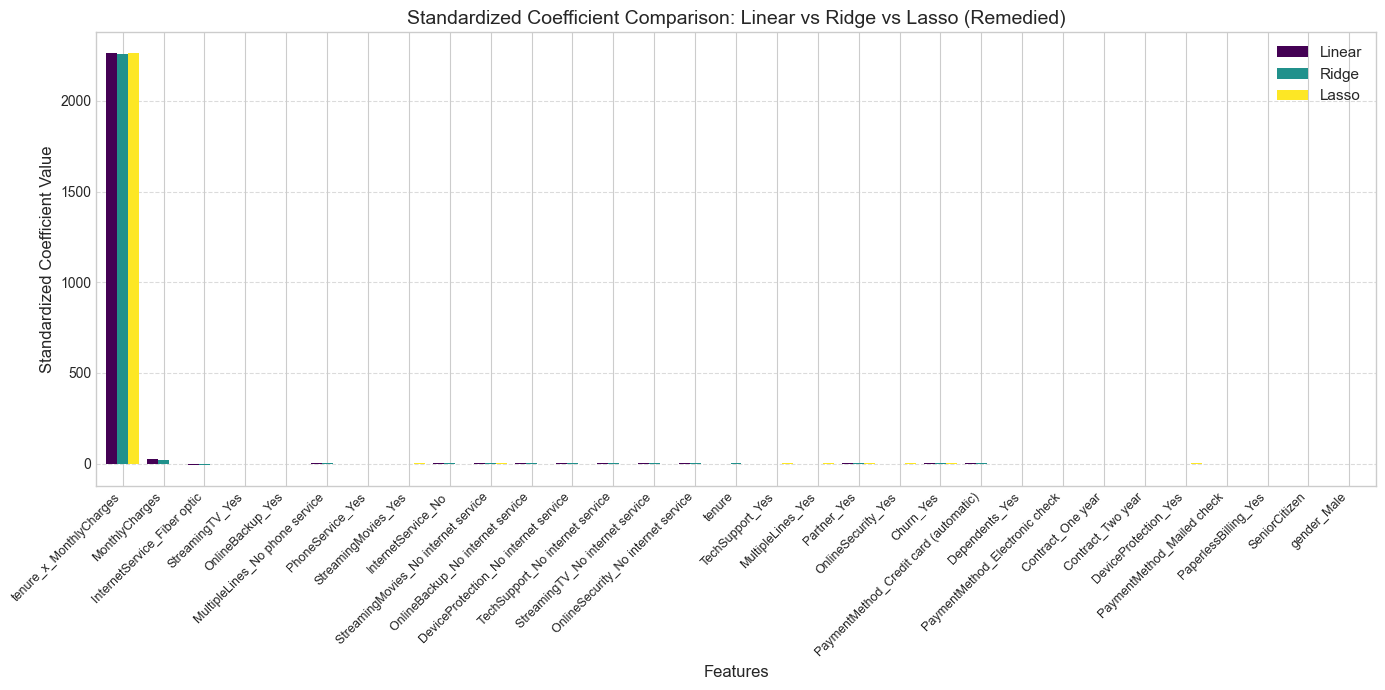

In [14]:
# Coefficient Comparison Plot
def plot_coefficients(lr_model, ridge_model, lasso_model, feature_names):
    coef_df = pd.DataFrame({
        "Linear": lr_model.coef_,
        "Ridge": ridge_model.coef_,
        "Lasso": lasso_model.coef_
    }, index=feature_names)

    # Sort by magnitude of Linear Regression coefficients for clear display
    coef_df["abs_linear"] = coef_df["Linear"].abs()
    coef_df = coef_df.sort_values(by="abs_linear", ascending=False).drop(columns=["abs_linear"])

    plt.figure(figsize=(14, 7))
    coef_df.plot(kind="bar", width=0.8, figsize=(14, 7), colormap="viridis")
    plt.title("Standardized Coefficient Comparison: Linear vs Ridge vs Lasso (Remedied)", fontsize=14)
    plt.xlabel("Features", fontsize=12)
    plt.ylabel("Standardized Coefficient Value", fontsize=12)
    plt.legend(loc="best", fontsize=11)
    plt.xticks(rotation=45, ha="right", fontsize=9)
    plt.grid(axis="y", linestyle="--", alpha=0.7)
    plt.tight_layout()
    plt.show()

plot_coefficients(lr_model, ridge_model, lasso_model, X_remedied.columns)

### Coefficient Insights:
- `tenure * MonthlyCharges` has by far the largest positive standardized coefficient, indicating that this engineered feature has the strongest influence on the model's predictions.
- `MonthlyCharges` also has a positive coefficient, suggesting that higher monthly charges are associated with higher predicted values of the target, assuming the target is coded so that a higher value represents the outcome of interest.
- Most other features have coefficients close to zero, indicating relatively weak contributions to the prediction when the other variables are held constant.
- Ridge Regression shrinks coefficients toward zero while generally retaining all features, which helps reduce the influence of multicollinearity without completely removing variables.
- Lasso Regression applies stronger shrinkage and sets some coefficients exactly to zero, effectively performing feature selection by removing features that contribute little additional predictive information.
- The similar coefficient patterns across the three models suggest that the strongest relationships are relatively stable, while regularization mainly reduces the influence of weaker features.

This pattern is expected in a model where a few variables explain most of the variation in `TotalCharges`, while many categorical indicators contribute only modestly once the larger effects are accounted for.

## 6. Limitation(s) for Using Linear Regression for Churn

For this assignment, the model predicts `TotalCharges`, which is a continuous outcome. However, customer churn itself is a binary outcome (churn = 1, no churn = 0), so linear regression is not the ideal model for actual churn prediction.

### Key Limitations of Linear Regression for Customer Churn Prediction:

1. **Unbounded Output vs. Probabilities [0, 1]:**
   - Churn is a binary categorical outcome. Linear regression predicts unbounded continuous values from $-\infty$ to $+\infty$, which can produce invalid predicted probabilities below 0 or above 1.

2. **Violation of Normal Residuals & Non-Continuous Errors:**
   - For a binary target, the response is discrete rather than continuous, so the residual distribution is not expected to be normally distributed. This violates a key assumption behind ordinary least squares.

3. **Non-Linear Relationship (Sigmoidal vs. Linear):**
   - The relationship between customer characteristics and churn probability is often S-shaped rather than linear. Logistic regression, or tree-based classifiers such as Random Forest and XGBoost, are better suited because they model the logit relationship more appropriately.

Overall, this notebook shows how to evaluate linear regression assumptions, but it also highlights why a classification model is more appropriate for real churn prediction tasks.

These limitations reinforce the core takeaway: linear regression is a useful diagnostic and explanatory tool for a continuous outcome such as `TotalCharges`, but a binary classification model is more appropriate for predicting actual customer churn.